# Comparación de modelos con scikit-learn

**Objetivo:** elegir el modelo final del proyecto.

Se comparan tres algoritmos con **el mismo preprocesamiento, la misma partición y las mismas métricas**:

| Modelo | Por qué se incluye |
|---|---|
| Árbol de decisión | Línea base: simple y fácil de leer |
| Regresión logística | Modelo lineal, interpretable por coeficientes |
| Random Forest | Conjunto de árboles, suele mejorar a un árbol individual |

El preprocesamiento es el pipeline descrito en `modelo/pipeline.ipynb`.

In [1]:
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, recall_score, precision_score,
                             accuracy_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

sys.path.append("../modelo")  # transformadores propios del proyecto
from transformadores import LimpiarTotalCharges, EliminarColumnas, CrearCantidadServicios, MapearBinarias

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Un color fijo por modelo en todos los gráficos
COLORES = {"Árbol de decisión": "#2a78d6", "Regresión logística": "#eb6834", "Random Forest": "#1baf7a"}

## 1. Datos y partición

80 % para entrenamiento y 20 % para prueba, con partición estratificada y semilla fija (`random_state=42`). Es la misma partición que usa el resto del proyecto, para que los resultados sean comparables.

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(5634, 20) (1409, 20)


## 2. Un mismo pipeline para los tres modelos

Lo único que cambia entre modelos es el último paso y, para la regresión logística, el escalado de las variables numéricas: los árboles no lo necesitan, pero un modelo lineal regularizado sí.

In [3]:
columnas_servicios = ["OnlineBackup", "DeviceProtection", "StreamingTV", "StreamingMovies"]
binarias = ["Partner", "Dependents", "PaperlessBilling", "OnlineSecurity", "TechSupport"]
nominales = ["InternetService", "Contract", "PaymentMethod"]
numericas = ["tenure", "MonthlyCharges", "TotalCharges", "cantidad_servicios"]

def crear_pipeline(modelo, escalar=False):
    transformadores = [("nominales", OneHotEncoder(drop="first", handle_unknown="ignore"), nominales)]
    if escalar:
        transformadores.append(("numericas", StandardScaler(), numericas))

    return Pipeline([
        ("limpiar_totalcharges", LimpiarTotalCharges()),
        ("eliminar_columnas", EliminarColumnas(["gender", "PhoneService", "MultipleLines", "customerID"])),
        ("crear_cantidad_servicios", CrearCantidadServicios(columnas_servicios)),
        ("mapear_binarias", MapearBinarias(binarias)),
        ("encoding_nominales", ColumnTransformer(transformadores, remainder="passthrough")),
        ("modelo", modelo),
    ])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 3. Ajuste de hiperparámetros

Cada modelo se ajusta con una búsqueda en rejilla pequeña, validación cruzada de 5 particiones y la misma métrica (F1), usando solo el conjunto de entrenamiento. El conjunto de prueba no se toca hasta el final.

Se usa F1 y no recall porque el recall se puede inflar marcando a casi todos los clientes como riesgo: un árbol de un solo nivel alcanza un recall de 0,97 con una precisión muy baja. F1 obliga a equilibrar ambas cosas.

Los tres modelos usan `class_weight="balanced"` porque solo el 26,5 % de los clientes cancela.

In [4]:
busqueda_arbol = GridSearchCV(
    crear_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    param_grid={"modelo__max_depth": [1, 2, 3, 4, 5, 6, 8, 10]},
    scoring={"f1": "f1", "recall": "recall", "precision": "precision"}, refit="f1", cv=skf, n_jobs=-1,
).fit(X_train, y_train)

print("Árbol de decisión:", busqueda_arbol.best_params_, f"F1 CV = {busqueda_arbol.best_score_:.3f}")

pd.DataFrame({
    "max_depth": [p["modelo__max_depth"] for p in busqueda_arbol.cv_results_["params"]],
    "F1": busqueda_arbol.cv_results_["mean_test_f1"],
    "Recall": busqueda_arbol.cv_results_["mean_test_recall"],
    "Precisión": busqueda_arbol.cv_results_["mean_test_precision"],
}).set_index("max_depth").round(3)

Árbol de decisión: {'modelo__max_depth': 6} F1 CV = 0.617


,F1,Recall,Precisión
max_depth,,,
1,0.505,0.974,0.341
2,0.577,0.887,0.428
3,0.577,0.887,0.428
4,0.613,0.783,0.505
5,0.605,0.750,0.509
6,0.617,0.811,0.497
8,0.608,0.776,0.500
10,0.589,0.732,0.493


In [5]:
busqueda_lr = GridSearchCV(
    crear_pipeline(LogisticRegression(class_weight="balanced", max_iter=2000), escalar=True),
    param_grid={"modelo__C": [0.01, 0.1, 1, 10]},
    scoring="f1", cv=skf, n_jobs=-1,
).fit(X_train, y_train)

print("Regresión logística:", busqueda_lr.best_params_, f"F1 CV = {busqueda_lr.best_score_:.3f}")

Regresión logística: {'modelo__C': 0.01} F1 CV = 0.631


In [6]:
busqueda_rf = GridSearchCV(
    crear_pipeline(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
    param_grid={"modelo__max_depth": [4, 6, 8, 10, None], "modelo__min_samples_leaf": [1, 5, 10, 20]},
    scoring="f1", cv=skf, n_jobs=1,
).fit(X_train, y_train)

print("Random Forest:", busqueda_rf.best_params_, f"F1 CV = {busqueda_rf.best_score_:.3f}")

Random Forest: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 5} F1 CV = 0.637


In [7]:
modelos = {
    "Árbol de decisión": busqueda_arbol.best_estimator_,
    "Regresión logística": busqueda_lr.best_estimator_,
    "Random Forest": busqueda_rf.best_estimator_,
}

## 4. Validación cruzada (entrenamiento)

Media y desviación estándar de cada métrica en las cinco particiones.

In [8]:
metricas = {"roc_auc": "ROC-AUC", "f1": "F1", "recall": "Recall", "precision": "Precisión"}

filas = {}
for nombre, pipe in modelos.items():
    cv = cross_validate(pipe, X_train, y_train, cv=skf, scoring=list(metricas))
    filas[nombre] = {etiqueta: f"{cv['test_' + m].mean():.3f} ± {cv['test_' + m].std():.3f}" for m, etiqueta in metricas.items()}

pd.DataFrame(filas).T

,ROC-AUC,F1,Recall,Precisión
Árbol de decisión,0.825 ± 0.014,0.617 ± 0.012,0.811 ± 0.009,0.497 ± 0.016
Regresión logística,0.840 ± 0.012,0.631 ± 0.019,0.778 ± 0.032,0.531 ± 0.013
Random Forest,0.842 ± 0.012,0.637 ± 0.018,0.763 ± 0.028,0.546 ± 0.015


## 5. Evaluación en el conjunto de prueba

Cada modelo se entrena con todo el conjunto de entrenamiento y se evalúa sobre los 1.409 clientes que no ha visto.

In [9]:
predicciones, probabilidades, filas = {}, {}, {}

for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    predicciones[nombre] = pipe.predict(X_test)
    probabilidades[nombre] = pipe.predict_proba(X_test)[:, 1]
    filas[nombre] = {
        "ROC-AUC": roc_auc_score(y_test, probabilidades[nombre]),
        "F1": f1_score(y_test, predicciones[nombre]),
        "Recall": recall_score(y_test, predicciones[nombre]),
        "Precisión": precision_score(y_test, predicciones[nombre]),
        "Accuracy": accuracy_score(y_test, predicciones[nombre]),
    }

resultados_test = pd.DataFrame(filas).T.round(3)
resultados_test

,ROC-AUC,F1,Recall,Precisión,Accuracy
Árbol de decisión,0.823,0.620,0.802,0.505,0.739
Regresión logística,0.835,0.616,0.786,0.507,0.740
Random Forest,0.842,0.631,0.762,0.538,0.763


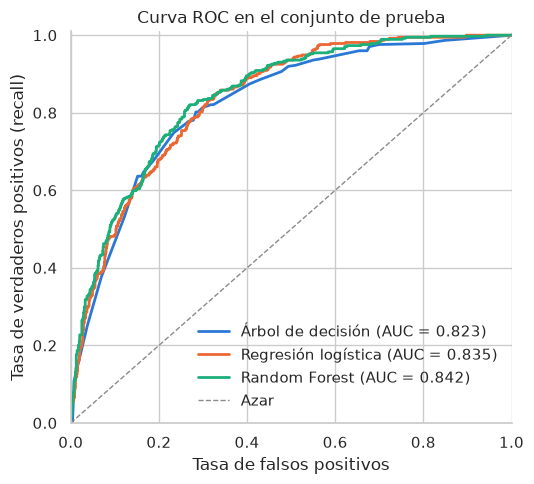

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))

for nombre in modelos:
    fpr, tpr, _ = roc_curve(y_test, probabilidades[nombre])
    auc = resultados_test.loc[nombre, "ROC-AUC"]
    ax.plot(fpr, tpr, color=COLORES[nombre], linewidth=2, label=f"{nombre} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color="#8a8a86", linestyle="--", linewidth=1, label="Azar")
ax.set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos (recall)",
       title="Curva ROC en el conjunto de prueba", xlim=(0, 1), ylim=(0, 1.01))
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("../img/curva_roc.png", dpi=150, facecolor="white")
plt.show()

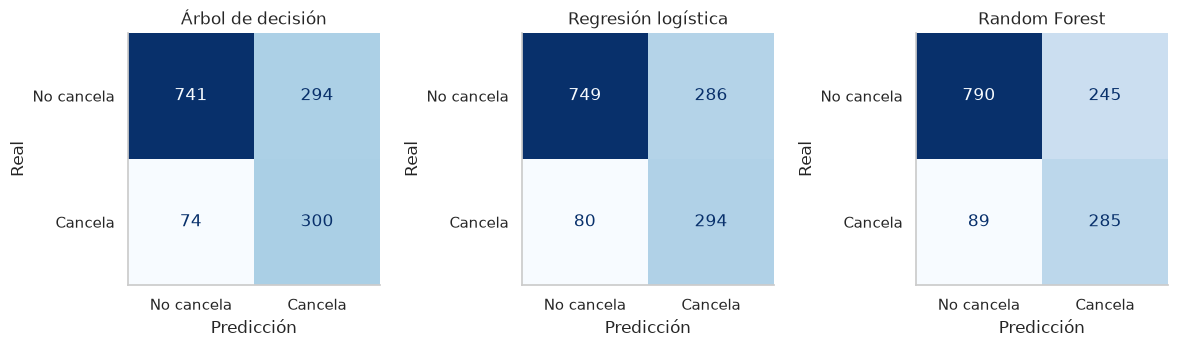

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

for ax, nombre in zip(axes, modelos):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predicciones[nombre], display_labels=["No cancela", "Cancela"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set(title=nombre, xlabel="Predicción", ylabel="Real")
    ax.grid(False)

plt.tight_layout()
plt.show()

### Precisión a igual recall

Con el umbral por defecto (0,5) cada modelo queda en un punto distinto del equilibrio entre recall y precisión, y eso dificulta compararlos. La tabla muestra qué precisión alcanza cada uno cuando se mueve su umbral hasta detectar la misma proporción de cancelaciones.

In [12]:
niveles_recall = [0.70, 0.75, 0.80, 0.85, 0.90]

filas = {}
for nombre in modelos:
    precision, recall, _ = precision_recall_curve(y_test, probabilidades[nombre])
    # Para cada nivel, la mejor precisión entre los umbrales que alcanzan ese recall
    filas[nombre] = {f"Recall {nivel:.0%}": precision[recall >= nivel].max() for nivel in niveles_recall}

pd.DataFrame(filas).T.round(3)

,Recall 70%,Recall 75%,Recall 80%,Recall 85%,Recall 90%
Árbol de decisión,0.536,0.518,0.505,0.438,0.406
Regresión logística,0.540,0.520,0.498,0.480,0.435
Random Forest,0.570,0.548,0.529,0.482,0.445


## 6. ¿En qué se fijan los modelos?

Importancia de las variables en el Random Forest y coeficientes de la regresión logística (las variables numéricas están escaladas y el resto vale 0 o 1).

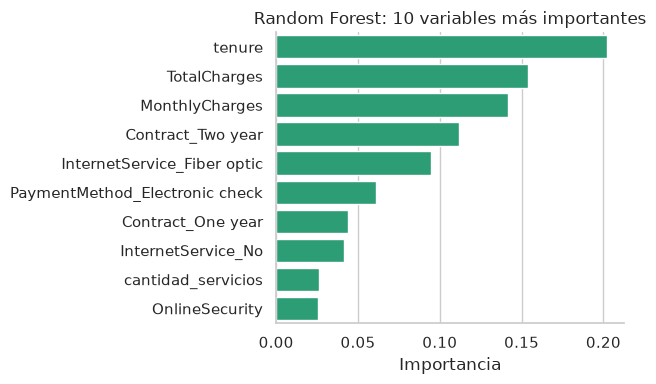

In [13]:
def nombres_limpios(pipe):
    nombres = pipe.named_steps["encoding_nominales"].get_feature_names_out()
    return [n.split("__", 1)[1] for n in nombres]

rf = modelos["Random Forest"]
importancias = (pd.Series(rf.named_steps["modelo"].feature_importances_, index=nombres_limpios(rf))
                  .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(x=importancias.values, y=importancias.index, color=COLORES["Random Forest"], ax=ax)
ax.set(xlabel="Importancia", ylabel="", title="Random Forest: 10 variables más importantes")
plt.tight_layout()
plt.show()

In [14]:
lr = modelos["Regresión logística"]
coeficientes = pd.Series(lr.named_steps["modelo"].coef_[0], index=nombres_limpios(lr))
orden = coeficientes.abs().sort_values(ascending=False).head(10).index

pd.DataFrame({
    "coeficiente": coeficientes[orden].round(2),
    "efecto": np.where(coeficientes[orden] > 0, "sube el riesgo", "baja el riesgo"),
})

,coeficiente,efecto
tenure,-0.68,baja el riesgo
Contract_Two year,-0.59,baja el riesgo
InternetService_Fiber optic,0.43,sube el riesgo
MonthlyCharges,0.42,sube el riesgo
InternetService_No,-0.39,baja el riesgo
PaymentMethod_Electronic check,0.38,sube el riesgo
Contract_One year,-0.36,baja el riesgo
OnlineSecurity,-0.34,baja el riesgo
TechSupport,-0.32,baja el riesgo
PaperlessBilling,0.31,sube el riesgo


## 7. Conclusiones

- **Random Forest es el mejor modelo en F1 y ROC-AUC.** En prueba obtiene F1 0,631 y ROC-AUC 0,842, frente a 0,616 y 0,835 de la regresión logística y 0,620 y 0,823 del árbol. El orden es el mismo en validación cruzada, así que no depende de la partición.
- **Con el umbral por defecto, el árbol detecta más cancelaciones, pero a costa de más falsas alarmas.** El árbol encuentra 300 de las 374 cancelaciones y el Random Forest 285, pero el árbol señala por error a 294 clientes que no cancelan y el Random Forest a 245.
- **A igual recall, Random Forest siempre es más preciso.** Si se ajusta el umbral para que todos detecten el 80 % de las cancelaciones, su precisión es 0,529 frente a 0,505 del árbol y 0,498 de la regresión logística. Lo mismo ocurre en los demás niveles de la tabla.
- **Las diferencias son moderadas.** La ventaja en F1 es de 1 a 2 centésimas, del mismo orden que la variación entre particiones (±0,02). Los tres modelos se apoyan en las mismas variables: antigüedad, tipo de contrato, tipo de internet y cargos.

### Decisión

El modelo final del proyecto es el **Random Forest** (`n_estimators=300`, `min_samples_leaf=5`, sin límite de profundidad, clases balanceadas). Se entrena y se guarda con `modelo/modelo.py`, y se evalúa y explica en `pruebas/evaluacion_shap.ipynb`.

Se mantiene el umbral de 0,5. Como siguiente paso, el umbral se podría ajustar según cuánto cuesta contactar a un cliente frente a cuánto cuesta perderlo.